In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [ ]:
 !wget "https://drive.google.com/uc?export=download&id=1lEccW5Y5_2z00VRtLGOAJOAU6YA9fl6W" -O E-commerce.csv

--2026-04-10 17:16:40--  https://drive.google.com/uc?export=download&id=1lEccW5Y5_2z00VRtLGOAJOAU6YA9fl6W
Resolving drive.google.com (drive.google.com)... 142.251.108.139, 142.251.108.100, 142.251.108.101, ...
Connecting to drive.google.com (drive.google.com)|142.251.108.139|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1lEccW5Y5_2z00VRtLGOAJOAU6YA9fl6W&export=download [following]
--2026-04-10 17:16:40--  https://drive.usercontent.google.com/download?id=1lEccW5Y5_2z00VRtLGOAJOAU6YA9fl6W&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 192.178.142.132, 2607:f8b0:4023:80d::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|192.178.142.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 139827 (137K) [application/octet-stream]
Saving to: ‘E-commerce.csv’

E-commerce.csv      100%[===================>] 136.55K  --.

In [ ]:
df = pd.read_csv('./E-commerce.csv')
df.head()

,ID,n_clicks,n_visits,amount_spent,amount_discount,days_since_registration,profile_information
0,1476,130,65,213.905831,31.600751,233,235
1,1535,543,46,639.223004,5.689175,228,170
2,1807,520,102,1157.402763,844.321606,247,409
3,1727,702,83,1195.903634,850.041757,148,200
4,1324,221,84,180.754616,64.283300,243,259


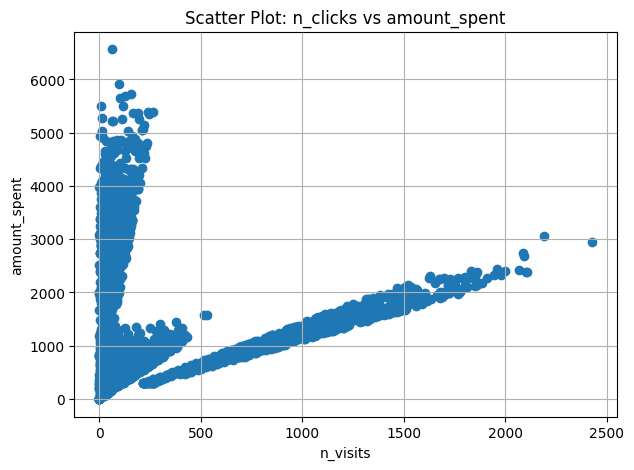

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(df["amount_discount"], df["amount_spent"])
plt.xlabel("n_visits")
plt.ylabel("amount_spent")
plt.title("Scatter Plot: n_clicks vs amount_spent")
plt.grid(True)
plt.show()

In [ ]:
df = pd.read_csv('./E-commerce.csv')
df.head()

,ID,n_clicks,n_visits,amount_spent,amount_discount,days_since_registration,profile_information
0,1476,130,65,213.905831,31.600751,233,235
1,1535,543,46,639.223004,5.689175,228,170
2,1807,520,102,1157.402763,844.321606,247,409
3,1727,702,83,1195.903634,850.041757,148,200
4,1324,221,84,180.754616,64.283300,243,259


In [ ]:
from sklearn.preprocessing import StandardScaler

X = df[["amount_spent", "amount_discount"]]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.1,        # to be tuned
    min_samples=15  # rule of thumb
)

labels = dbscan.fit_predict(X_scaled)

df["cluster"] = labels

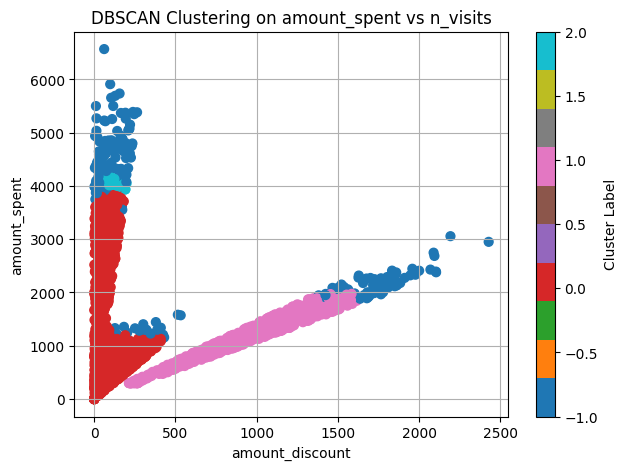

In [ ]:
plt.figure(figsize=(7,5))

sc = plt.scatter(
    df["amount_discount"],
    df["amount_spent"],
    c=df["cluster"],
    cmap="tab10",
    s=40
)

plt.xlabel("amount_discount")
plt.ylabel("amount_spent")
plt.title("DBSCAN Clustering on amount_spent vs n_visits")
plt.grid(True)

# add colorbar with label
cbar = plt.colorbar(sc)
cbar.set_label("Cluster Label")

plt.show()

In [ ]:
df["cluster"].unique()

array([ 0, -1])

In [ ]:
from sklearn.metrics import silhouette_score
mask = labels != -1

# need at least 2 clusters after removing noise
if len(set(labels[mask])) > 1:
    score = silhouette_score(X_scaled[mask], labels[mask])
    print("Silhouette Score:", score)
else:
    print("Not enough clusters to compute silhouette score")

Not enough clusters to compute silhouette score
